# EDA — creditcard.csv (Bank Credit Card Transactions)

**Task 1 · Adey Innovations Fraud Detection**

This notebook covers:
1. Data loading & cleaning
2. Univariate analysis of anonymised PCA features
3. Amount and Time analysis
4. Class imbalance quantification


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_loader import load_creditcard, clean_creditcard
from eda_utils   import (plot_class_imbalance, plot_numeric_distributions,
                          plot_correlation_heatmap)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Imports OK')


Imports OK


## 1. Load Data

In [7]:
# Update this path if creditcard.csv is stored elsewhere
DATA_DIR = '../data'
df_raw = load_creditcard(f'{DATA_DIR}/raw/creditcard.csv')
print(df_raw.shape)
df_raw.head(3)


INFO | CreditCard loaded: 284807 rows, 31 cols


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [8]:
print(df_raw.dtypes)
print()
df_raw.describe().T.round(3)


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object



,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.860,47488.146,0.000,54201.500,84692.000,139320.500,172792.000
V1,284807.0,0.000,1.959,-56.408,-0.920,0.018,1.316,2.455
V2,284807.0,0.000,1.651,-72.716,-0.599,0.065,0.804,22.058
V3,284807.0,-0.000,1.516,-48.326,-0.890,0.180,1.027,9.383
V4,284807.0,0.000,1.416,-5.683,-0.849,-0.020,0.743,16.875
V5,284807.0,0.000,1.380,-113.743,-0.692,-0.054,0.612,34.802
V6,284807.0,0.000,1.332,-26.161,-0.768,-0.274,0.399,73.302
V7,284807.0,-0.000,1.237,-43.557,-0.554,0.040,0.570,120.589
V8,284807.0,0.000,1.194,-73.217,-0.209,0.022,0.327,20.007
V9,284807.0,-0.000,1.099,-13.434,-0.643,-0.051,0.597,15.595


## 2. Data Cleaning

In [9]:
# Missing values
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "  None — dataset is complete.")

# Duplicates
n_dups = df_raw.duplicated().sum()
print(f"\nDuplicate rows: {n_dups}")


Missing values per column:
  None — dataset is complete.

Duplicate rows: 1081


In [ ]:
df = clean_creditcard(df_raw)
print(f"Rows after cleaning: {len(df):,}")


## 3. Class Imbalance

INFO | CreditCard: dropped 1081 duplicates
INFO | CreditCard clean: 283726 rows remain


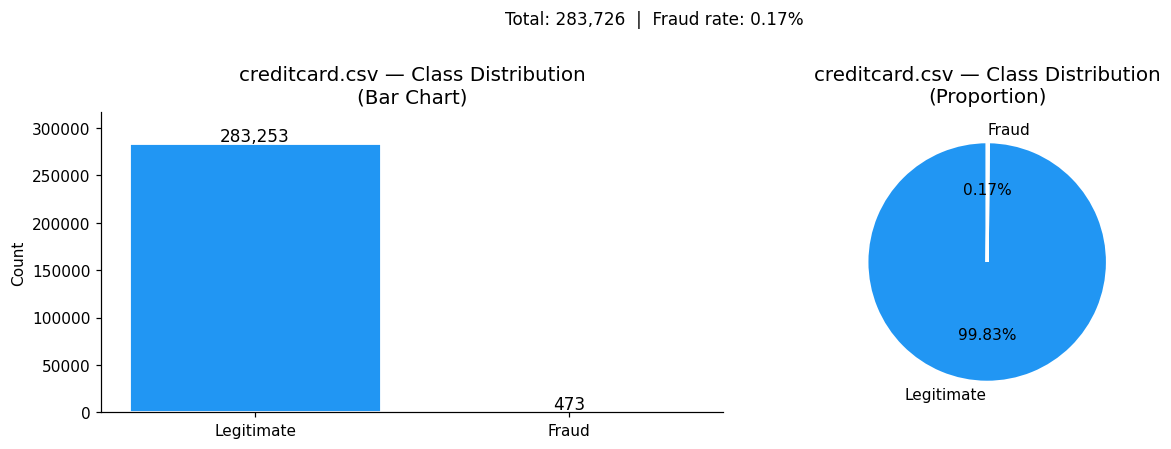

Legitimate: 283,253  |  Fraud: 473
Fraud rate: 0.1667%  →  Extreme imbalance

Standard accuracy of a naive 'always predict 0' model: 99.83%
This is why accuracy is a misleading metric here.


In [11]:
df = clean_creditcard(df_raw)

plot_class_imbalance(df['Class'], title='creditcard.csv — Class Distribution')

counts = df['Class'].value_counts().sort_index()
print(f"Legitimate: {counts[0]:,}  |  Fraud: {counts[1]:,}")
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%  →  Extreme imbalance")
print("\nStandard accuracy of a naive 'always predict 0' model:", f"{counts[0]/len(df)*100:.2f}%")
print("This is why accuracy is a misleading metric here.")


## 4. Time & Amount Analysis

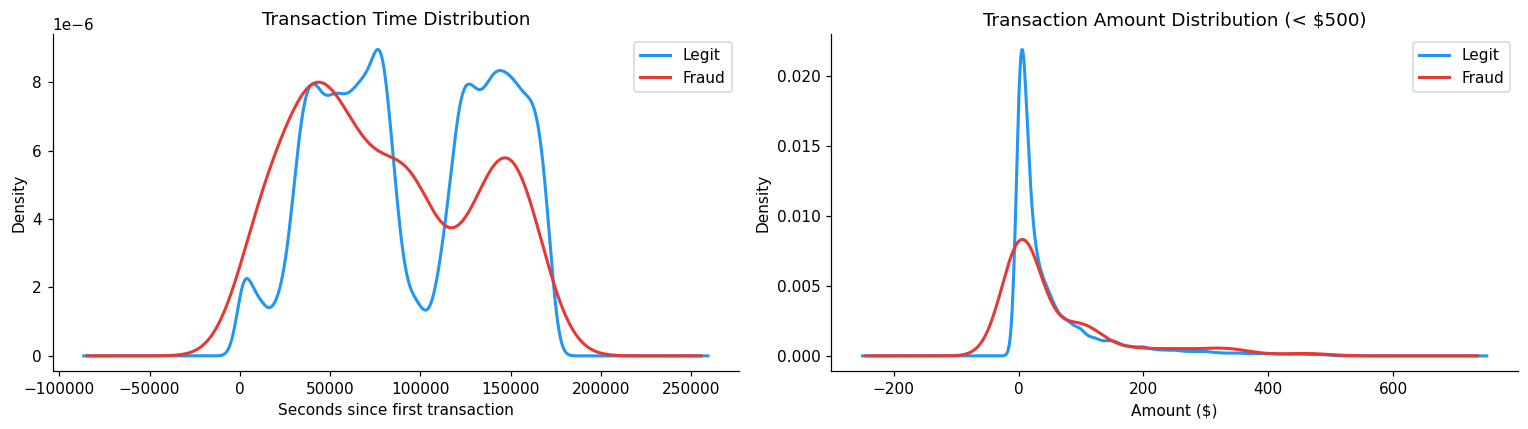

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time
for cls, label, color in [(0, 'Legit', '#2196F3'), (1, 'Fraud', '#E53935')]:
    df[df['Class']==cls]['Time'].plot.kde(ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_title('Transaction Time Distribution')
axes[0].set_xlabel('Seconds since first transaction')
axes[0].legend()

# Amount
for cls, label, color in [(0, 'Legit', '#2196F3'), (1, 'Fraud', '#E53935')]:
    vals = df[df['Class']==cls]['Amount']
    vals[vals < 500].plot.kde(ax=axes[1], label=label, color=color, linewidth=2)
axes[1].set_title('Transaction Amount Distribution (< $500)')
axes[1].set_xlabel('Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# Amount statistics by class
print("Amount statistics by Class:")
print(df.groupby('Class')['Amount'].describe().round(2))


Amount statistics by Class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87


## 5. PCA Feature Analysis (V1–V28)

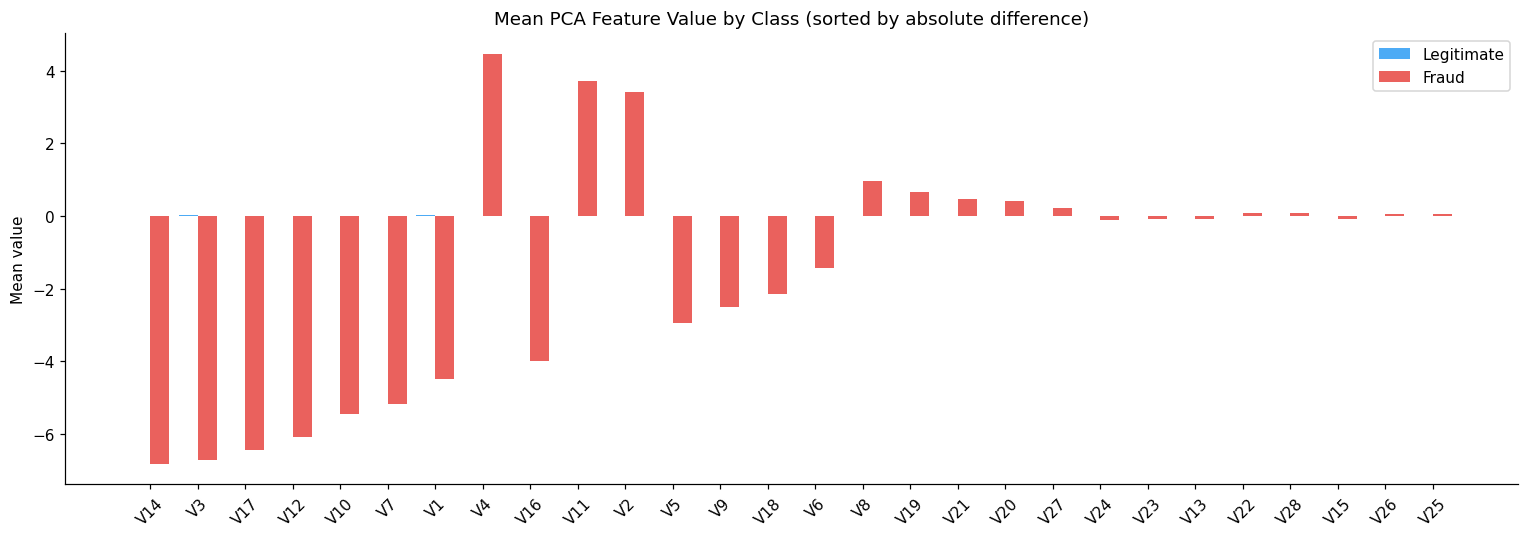

Top 10 most discriminative PCA features:
     Legitimate_mean  Fraud_mean    diff
V14           0.0117     -6.8359  6.8476
V3            0.0129     -6.7296  6.7425
V17           0.0110     -6.4633  6.4742
V12           0.0095     -6.1033  6.1127
V10           0.0077     -5.4533  5.4609
V7            0.0104     -5.1759  5.1864
V1            0.0134     -4.4983  4.5117
V4           -0.0104      4.4726  4.4830
V16           0.0078     -4.0010  4.0088
V11          -0.0060      3.7163  3.7224


In [14]:
# Mean value of each V feature by class — reveals which are most discriminative
V_COLS = [f'V{i}' for i in range(1, 29)]

means = df.groupby('Class')[V_COLS].mean().T
means.columns = ['Legitimate_mean', 'Fraud_mean']
means['diff'] = (means['Fraud_mean'] - means['Legitimate_mean']).abs()
means_sorted = means.sort_values('diff', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(V_COLS))
ax.bar([v - 0.2 for v in x], means_sorted['Legitimate_mean'], width=0.4,
       label='Legitimate', color='#2196F3', alpha=0.8)
ax.bar([v + 0.2 for v in x], means_sorted['Fraud_mean'], width=0.4,
       label='Fraud', color='#E53935', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(means_sorted.index, rotation=45)
ax.set_title('Mean PCA Feature Value by Class (sorted by absolute difference)')
ax.set_ylabel('Mean value')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 most discriminative PCA features:")
print(means_sorted.head(10).round(4))


## 6. Correlation Heatmap

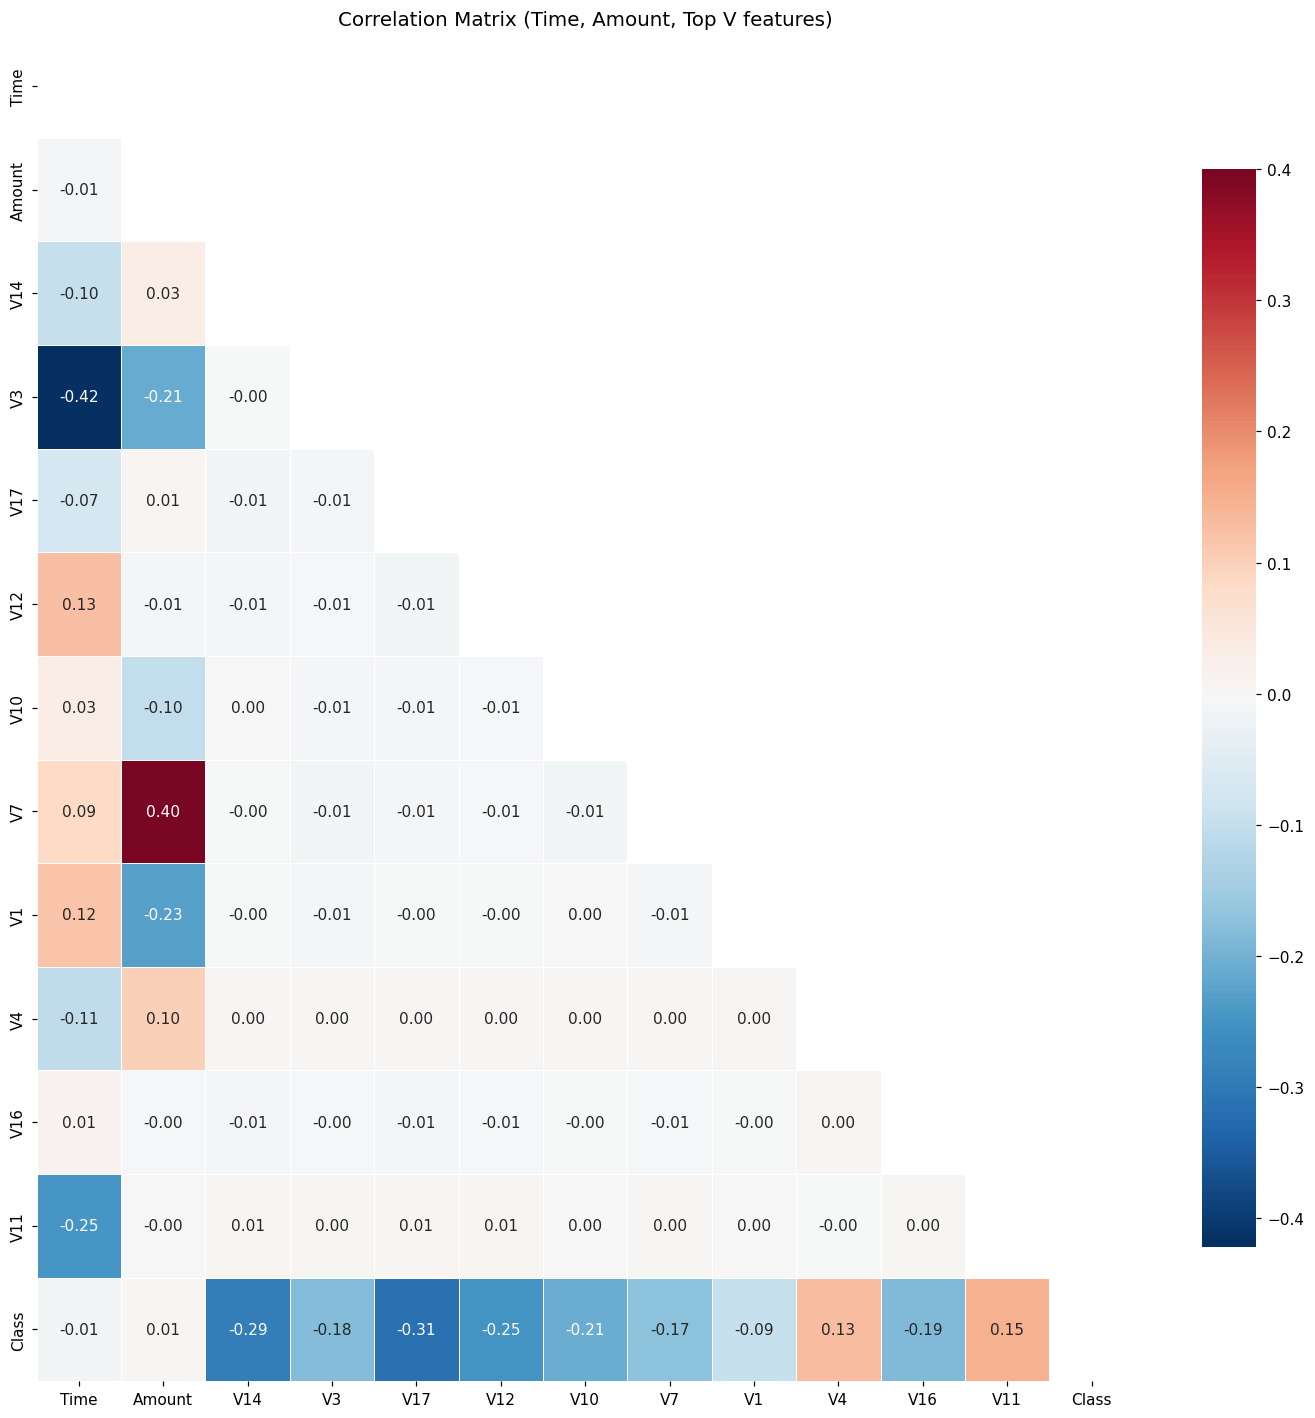

In [15]:
# Only show Time, Amount, Class and top 10 V features to keep it readable
top_v = means_sorted.head(10).index.tolist()
plot_cols = ['Time', 'Amount'] + top_v + ['Class']
plot_correlation_heatmap(df[plot_cols], title='Correlation Matrix (Time, Amount, Top V features)')


## 7. Save Cleaned Data

In [16]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/creditcard_clean.csv', index=False)
print("Saved: data/processed/creditcard_clean.csv")
print(f"Shape: {df.shape}")


Saved: data/processed/creditcard_clean.csv
Shape: (283726, 31)


## 8. EDA Summary

| Finding | Implication |
|---|---|
| Fraud rate = 0.17% | Extremely imbalanced — SMOTE essential on training set |
| Fraud amounts tend to be smaller | `Amount` is a useful feature post-scaling |
| V4, V11, V14, V17 show biggest mean differences | These will likely dominate feature importance |
| `Time` shows two usage peaks (day patterns) | Include `Time` scaled as a feature |
